# Unsupervised Machine Learning: Multicollinearity, Dimension Reduction, and Clustering

In [1]:
import ssl
import certifi
from urllib.request import urlopen
import ssl
import certifi
from urllib.request import urlopen
import pandas as pd

# Importar el dataser

url_data = 'https://gist.githubusercontent.com/wmeints/80c1ba22ceeb7a29a0e5e979f0b0afba/raw/8629fe51f0e7642fc5e05567130807b02a93af5e/auto-mpg.csv'
ssl_context = ssl.create_default_context(cafile=certifi.where())

col_names = ['mpg','cylinders','displacement','horsepower','weight','acceleration','model year','origin','car name']
with urlopen(url_data, context=ssl_context) as response:
    data = pd.read_csv(response,skiprows=1, header=None, names=col_names)
    # skiprows=1 skips the first row of the CSV

df = pd.DataFrame(data)

df.head(7)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala


## 1. Entendimiento y limpieza del dataset 

In [3]:
"""
Detección de impurezas
"""
print("- Tipos de dato:")
print(df.dtypes)

print("\n- NaN por columna:")
print(df.isna().sum())

print("\n- Non-numeric values en lugares donde no corresponde:")
print((df == "?").sum())

print("\n- Valores únicos por columna:")
print(df.nunique())

print("\n-Columnas object:")
print(df.select_dtypes(include="object").columns.tolist())

- Tipos de dato:
mpg             float64
cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object

- NaN por columna:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

- Non-numeric values en lugares donde no corresponde:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

- Valores únicos por columna:
mpg             129
cylinders         5
displacement     82
horsepower       94
weight          351
acceleration     95
model year       13
origin            3
car name        305
dtype: int64

-Columnas object:
['horsepower', 'car name']


/var/folders/kr/zlpqlpw96cj2wmtlnvjrfzc40000gn/T/ipykernel_5756/1407564467.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())


In [4]:
"""
Limpieza del datase
"""
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


# horsepower: '?' -> NaN -> numérico
non_numeric_hp = df.loc[
    pd.to_numeric(df['horsepower'], errors='coerce').isna(),
    'horsepower'
].unique()
print("\nValores no numéricos en horsepower:", non_numeric_hp)

df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Imputar con mediana
median_hp = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(median_hp)
print(f"horsepower imputado con mediana = {median_hp:.2f}")

# Eliminar atributos irrelevantes
df = df.drop(columns=['car name', 'origin'], errors='ignore')

# Homogenización numérica
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print("\nResumen estandarizado:")
print(df_scaled.describe().round(2).loc[['mean', 'std']])

df_scaled.head(7)



Valores no numéricos en horsepower: <StringArray>
['?']
Length: 1, dtype: str
horsepower imputado con mediana = 93.50

Resumen estandarizado:
      mpg  cylinders  displacement  horsepower  weight  acceleration  \
mean  0.0       -0.0          -0.0        -0.0    -0.0          -0.0   
std   1.0        1.0           1.0         1.0     1.0           1.0   

      model year  
mean        -0.0  
std          1.0  


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,-0.706439,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426
1,-1.090751,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426
2,-0.706439,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426
3,-0.962647,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426
4,-0.834543,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426
5,-1.090751,1.498191,2.262118,2.454408,1.620492,-2.021656,-1.627426
6,-1.218855,1.498191,2.502182,3.030708,1.635863,-2.384735,-1.627426


## 2. Multicollinearity: Detección y corección

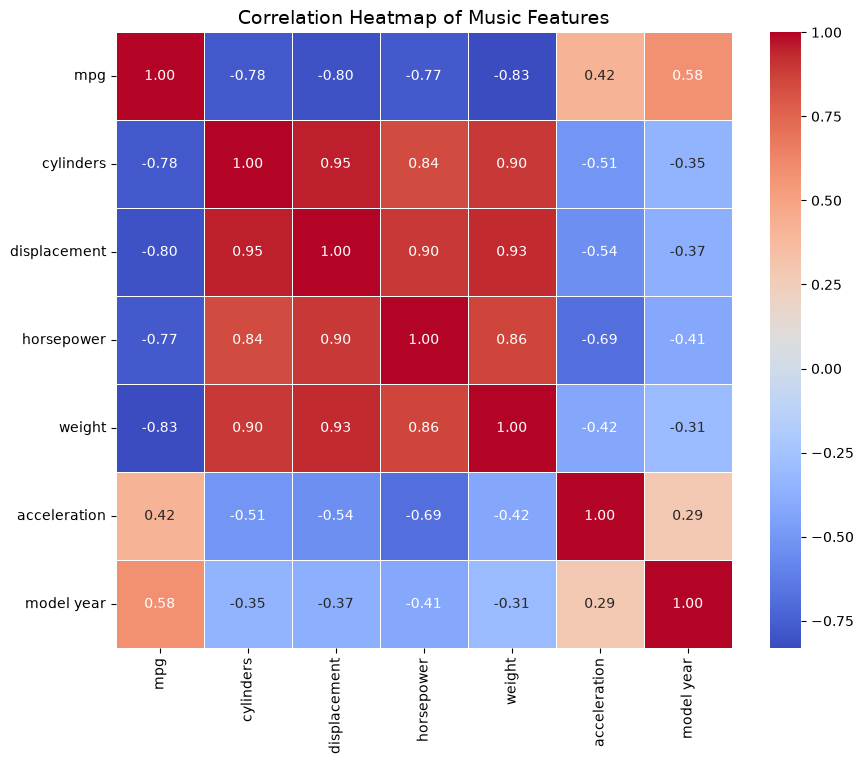

Pares con |r| > 0.8:
cylinders     displacement    0.950721
displacement  weight          0.932824
cylinders     weight          0.896017
displacement  horsepower      0.895778
horsepower    weight          0.862442
cylinders     horsepower      0.841284
mpg           weight         -0.831741
              displacement   -0.804203
dtype: float64


In [5]:
"""
Matriz de correlación
"""
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_scaled.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)

plt.title('Correlation Heatmap of Music Features', fontsize = 14)

plt.show()

threshold = 0.8
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
)
print("Pares con |r| > 0.8:")
print(high_corr[high_corr.abs() > threshold])

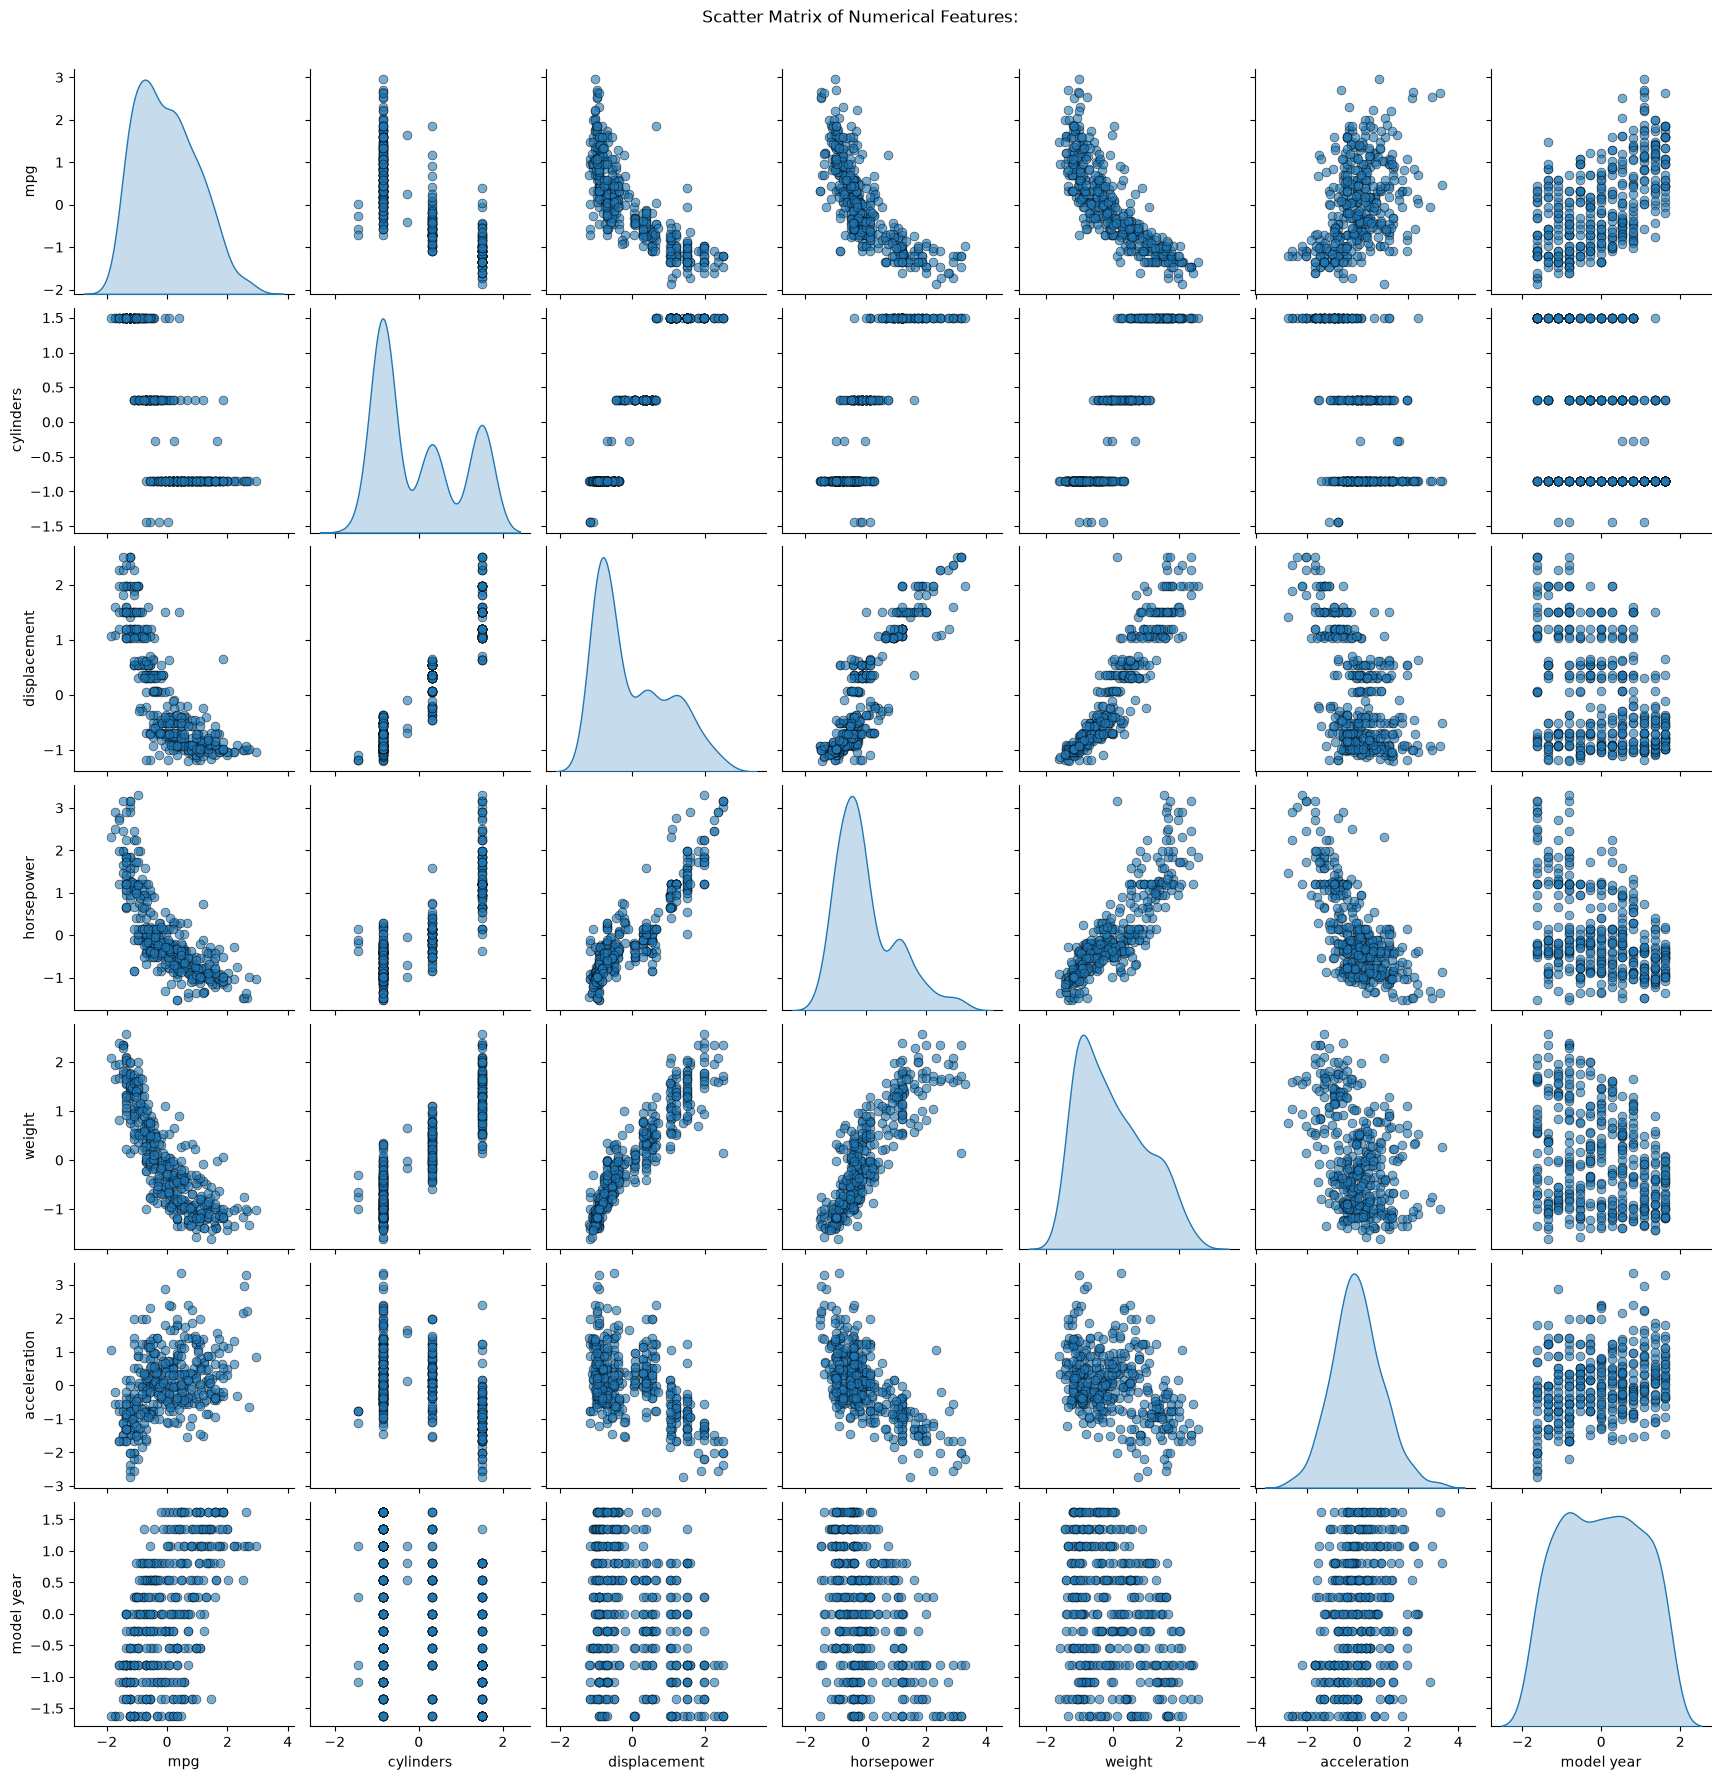

In [6]:
"""
Scatter matrix
"""
import seaborn as sns 
import matplotlib.pyplot as plt

numeric_df = df_scaled.select_dtypes(include=['float64', 'int64'])

sns.pairplot(numeric_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40, 'edgecolor':'k'})

plt.suptitle("Scatter Matrix of Numerical Features:", y=1.02)
plt.show()

In [7]:
"""
Cálculo de VIF
"""
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df_scaled)

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,const,1.000000
1,mpg,5.227609
2,cylinders,10.602332
3,displacement,19.792605
4,horsepower,9.003781
5,weight,13.516316
6,acceleration,2.559076
7,model year,1.915162


In [8]:
# Features con VIF a considerar
redundantes = vif[vif["VIF"] > 10]["Feature"].tolist()
print("Candidatas a eliminar por VIF > 10:", redundantes)

# De cada par muy correlacionado, conserva la de MENOR VIF
print("\nPares redundantes (|r| > 0.8):")
print(high_corr[high_corr.abs() > threshold])

Candidatas a eliminar por VIF > 10: ['cylinders', 'displacement', 'weight']

Pares redundantes (|r| > 0.8):
cylinders     displacement    0.950721
displacement  weight          0.932824
cylinders     weight          0.896017
displacement  horsepower      0.895778
horsepower    weight          0.862442
cylinders     horsepower      0.841284
mpg           weight         -0.831741
              displacement   -0.804203
dtype: float64


El **análisis de multicolinealidad** reveló un grupo de predictores fuertemente correlacionados: *cylinders, displacement, weight y horsepower* presentan coeficientes de correlación de Pearson entre 0.84 y 0.95. Por otro lado, el cálculo de VIF confirmó los resultados para *cylinders, displacement y weight*. Con esto en mente, la decisión a tomar será:

- Eliminar cylinders, pues es una categórica cuya información ya captura displacement
- Eliminar displacement, pues es redundante con weight y horsepower 
- Se conservará weight y horsepower por representar conceptos físicamente distintos y mantener interpretabilidad.


## 3. PCA

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Standardize the variables, compute the principal components, and calculate the explained variance ratio.
FEATURES = ['mpg', 'weight', 'horsepower', 'acceleration', 'model year']
X = df_scaled[FEATURES].copy()
print("Features finales:", X.columns.tolist())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

explained_variance = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

print("\nExplained Variance per Principal Component:")
display(explained_variance.round(4))

loadings = pd.DataFrame(pca.components_.T, # Loading coefficients
                        columns=[f'PC{i+1}' for i in range(len(X.columns))],
                        index=X.columns)

print("Principal Component Loadings:")
display(loadings.round(4))



Features finales: ['mpg', 'weight', 'horsepower', 'acceleration', 'model year']

Explained Variance per Principal Component:


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.6617,0.6617
1,PC2,0.1611,0.8228
2,PC3,0.1356,0.9584
3,PC4,0.0292,0.9875
4,PC5,0.0125,1.0000


Principal Component Loadings:


,PC1,PC2,PC3,PC4,PC5
mpg,-0.4988,0.2062,-0.2925,0.7403,0.2740
weight,0.4846,0.1776,0.4900,0.2242,0.6658
horsepower,0.5182,0.2397,0.0193,0.5239,-0.6318
acceleration,-0.3736,-0.4372,0.7402,0.2517,-0.2410
model year,-0.3290,0.8230,0.3551,-0.2527,-0.1563


In [ ]:
"""
Verificación PCA: PCs no correlacionados + multicolinealidad eliminada
"""
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

#  Matriz de correlación entre PCs 
# Nota mental: debe ser ≈ identidad
corr_pcs = X_pca_df.corr()
mask = ~np.eye(corr_pcs.shape[0], dtype=bool)
max_off = np.abs(corr_pcs.values[mask]).max()
print(f"Máxima |r| entre PCs distintos: {max_off:.2e}  (debe ser ≈ 0)")

# VIF de los PCs
# Nota mental: debe ser ≈ 1
X_pca_const = add_constant(X_pca_df)
vif_pcs = pd.DataFrame({
    'PC': X_pca_const.columns,
    'VIF': [variance_inflation_factor(X_pca_const.values, i)
            for i in range(X_pca_const.shape[1])]
})
vif_pcs = vif_pcs[vif_pcs['PC'] != 'const'].reset_index(drop=True)
display(vif_pcs.round(4))

Máxima |r| entre PCs distintos: 2.44e-15  (debe ser ≈ 0)


,PC,VIF
0,PC1,1.0
1,PC2,1.0
2,PC3,1.0
3,PC4,1.0
4,PC5,1.0


Tras el uso de PCA, la máxima correlación absoluta entre componentes distintos fue 2.44×10⁻¹⁵, lo que confirma la ortogonalidad de los componentes. Por otro lado, el VIF de todos los PCs resultó = 1, lo que evidencía que la multicolinealidad fue completamente eliminada.

Componentes necesarios para ≥90% varianza: 3


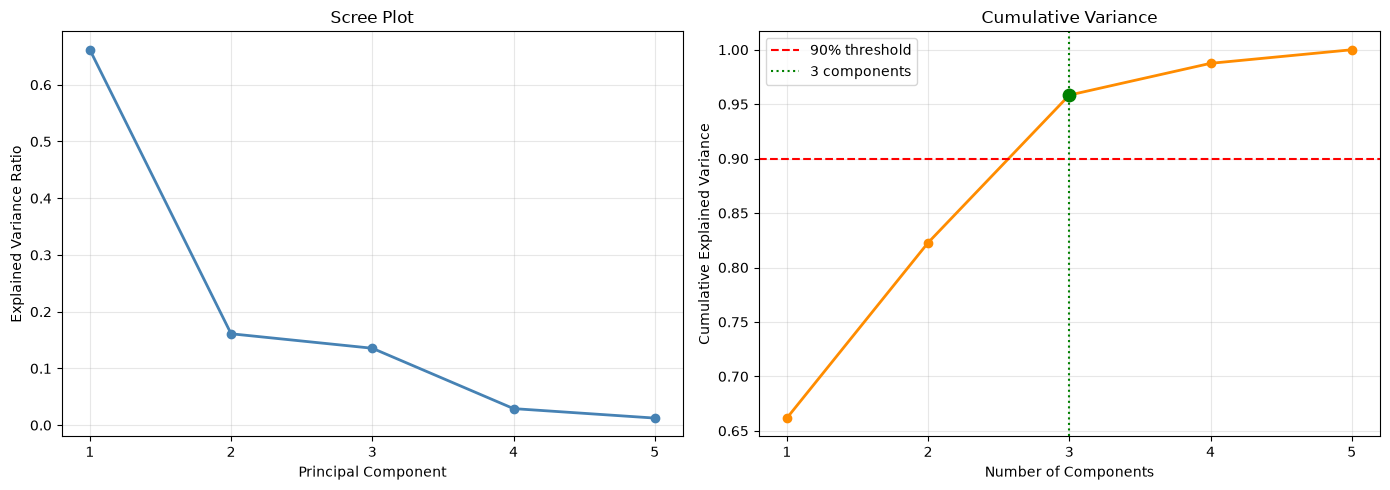

In [12]:
"""
Cumulative variance plot + cuántos componentes capturan ≥90%
"""
import numpy as np
import matplotlib.pyplot as plt

components = np.arange(1, len(pca.explained_variance_ratio_) + 1)
variance_ratio = pca.explained_variance_ratio_
cumulative = np.cumsum(variance_ratio)
n_comp_90 = int(np.argmax(cumulative >= 0.90) + 1)
print(f"Componentes necesarios para ≥90% varianza: {n_comp_90}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(components, variance_ratio, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(components)
axes[0].grid(alpha=0.3)

# Cumulative variance plot
axes[1].plot(components, cumulative, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axvline(x=n_comp_90, color='green', linestyle=':', 
                label=f'{n_comp_90} components')
axes[1].scatter(n_comp_90, cumulative[n_comp_90-1], color='green', s=80, zorder=5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance')
axes[1].set_xticks(components)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Usando 3 componentes → shape (398, 3)


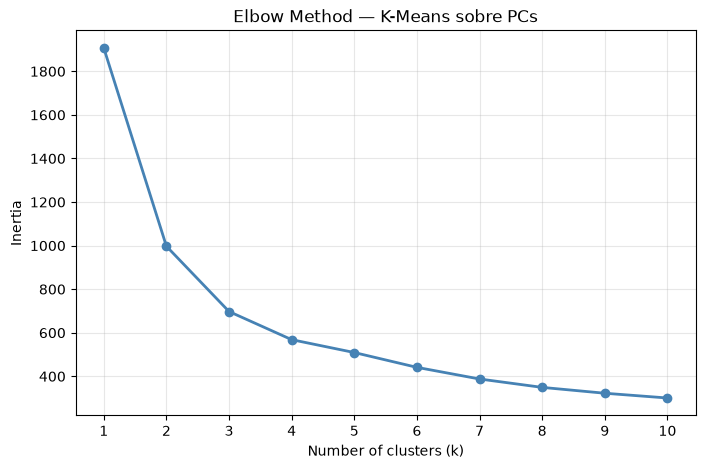

k óptimo por silhouette: 2 (score=0.4203)


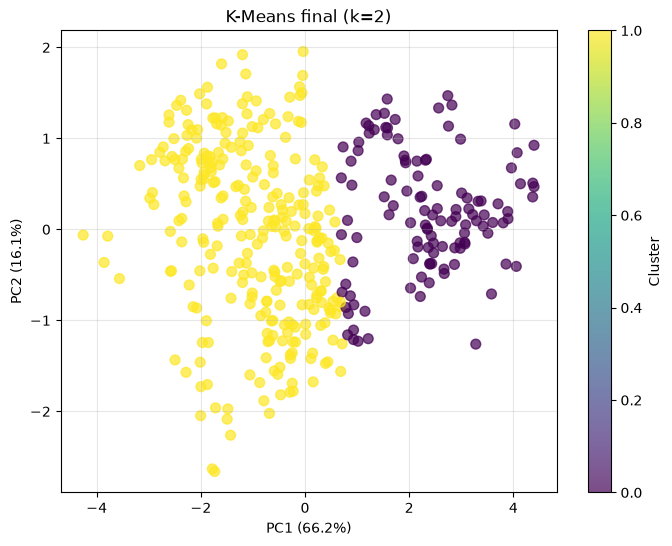

In [13]:
"""
K-Means: elbow plot + k óptimo por silhouette + modelo final
"""
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Reducir X_pca a los primeros n_comp_90 componentes según lq sección anterior
X_pca_reduced = X_pca[:, :n_comp_90]
print(f"Usando {n_comp_90} componentes → shape {X_pca_reduced.shape}")

# Elbow: inertia para k = 1..10
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca_reduced)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — K-Means sobre PCs')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.show()

# Silhouette para elegir k óptimo
sil_scores = {}
for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_pca_reduced)
    sil_scores[k] = silhouette_score(X_pca_reduced, labels)

k_opt = max(sil_scores, key=sil_scores.get)
print(f"k óptimo por silhouette: {k_opt} (score={sil_scores[k_opt]:.4f})")

# Modelo final
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels_km = km_final.fit_predict(X_pca_reduced)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km,
                      cmap='viridis', s=50, alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'K-Means final (k={k_opt})')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.show()

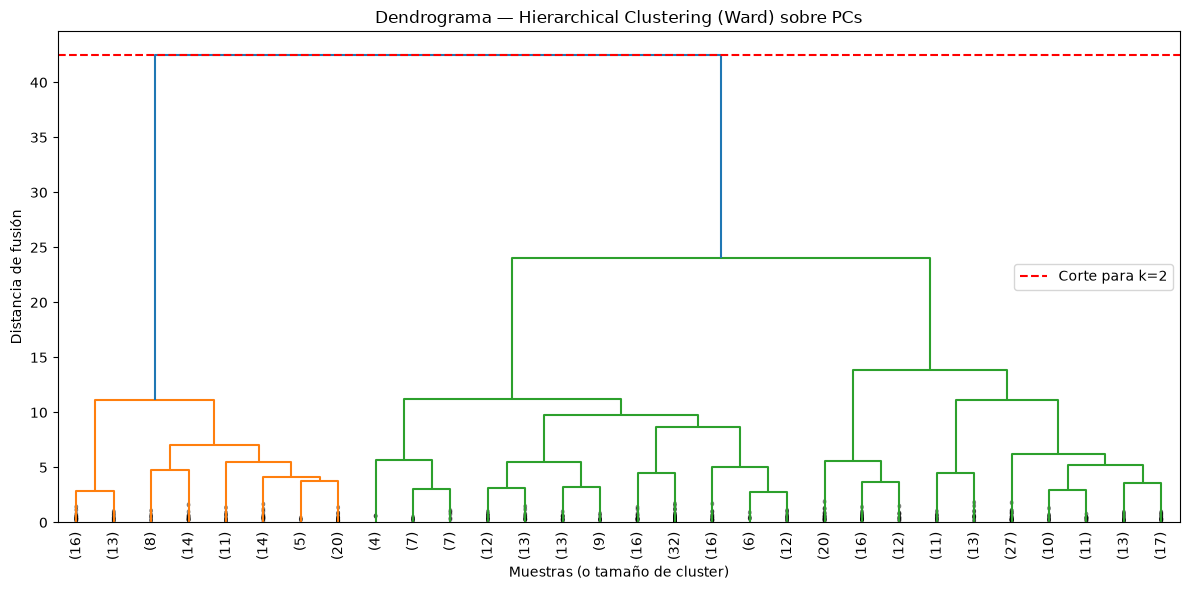

Silhouette hierarchical (k=2): 0.4383
Silhouette k-means      (k=2): 0.4203

Adjusted Rand Index (K-Means vs. Hierarchical): 0.8388
  → 1.0 = idénticos | 0.0 = aleatorio


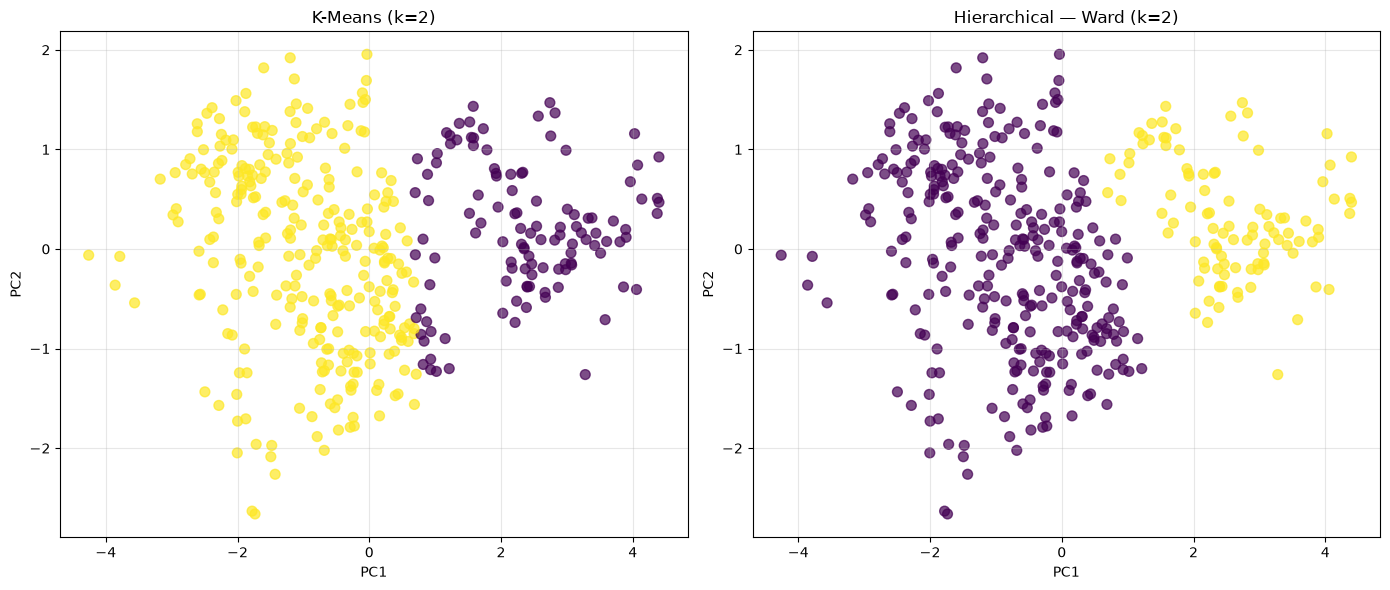

In [14]:
"""
Hierarchical clustering + dendrograma + comparación con K-Means
"""
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrograma 
Z = linkage(X_pca_reduced, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.axhline(y=Z[-k_opt+1, 2], color='red', linestyle='--',
            label=f'Corte para k={k_opt}')
plt.title('Dendrograma — Hierarchical Clustering (Ward) sobre PCs')
plt.xlabel('Muestras (o tamaño de cluster)')
plt.ylabel('Distancia de fusión')
plt.legend()
plt.tight_layout()
plt.show()

# Modelo jerárquico con el mismo k
hc = AgglomerativeClustering(n_clusters=k_opt, linkage='ward')
labels_hc = hc.fit_predict(X_pca_reduced)
sil_hc = silhouette_score(X_pca_reduced, labels_hc)
print(f"Silhouette hierarchical (k={k_opt}): {sil_hc:.4f}")
print(f"Silhouette k-means      (k={k_opt}): {sil_scores[k_opt]:.4f}")

# Comparación cuantitativa
ari = adjusted_rand_score(labels_km, labels_hc)
print(f"\nAdjusted Rand Index (K-Means vs. Hierarchical): {ari:.4f}")
print("  → 1.0 = idénticos | 0.0 = aleatorio")

# Comparación visual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km,
                cmap='viridis', s=50, alpha=0.7)
axes[0].set_title(f'K-Means (k={k_opt})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].grid(alpha=0.3)

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hc,
                cmap='viridis', s=50, alpha=0.7)
axes[1].set_title(f'Hierarchical — Ward (k={k_opt})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Perfil promedio por cluster (unidades originales):


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
Cluster,,,,,,,
0,15.08,7.66,326.89,152.95,4008.14,13.1,73.68
1,27.03,4.54,137.86,84.05,2538.35,16.6,76.98



Tamaño de cada cluster:


Cluster
0    117
1    281
Name: count, dtype: int64

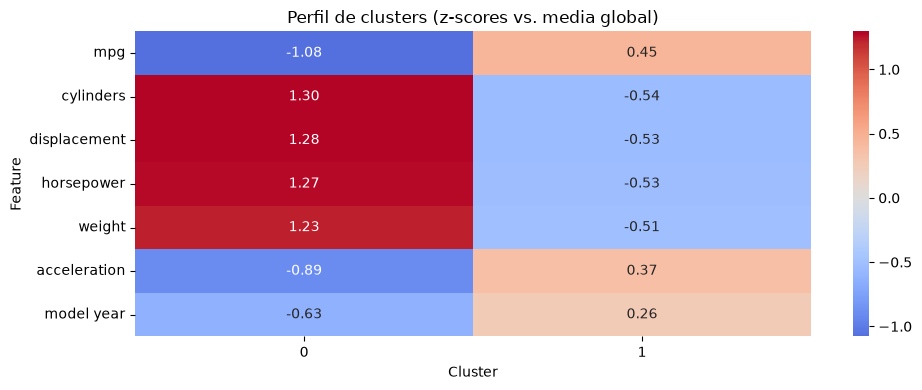

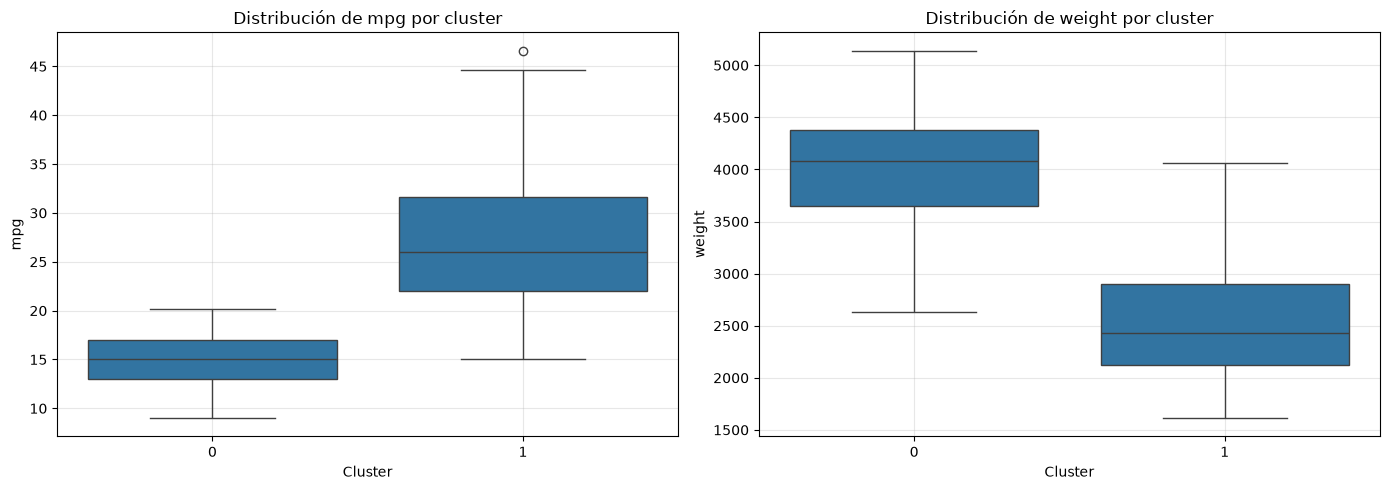

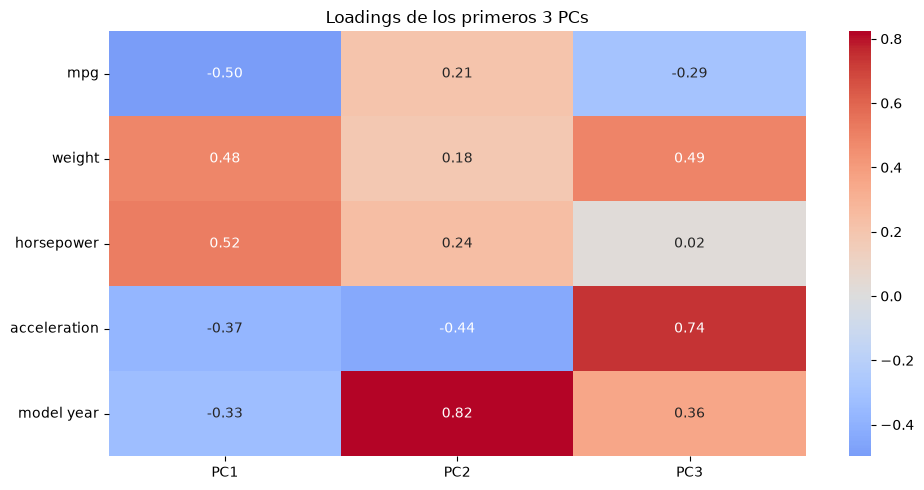


Interpretación de PCs:
  PC1: dominado por ['horsepower', 'mpg', 'weight']
  PC2: dominado por ['model year', 'acceleration', 'horsepower']
  PC3: dominado por ['acceleration', 'weight', 'model year']


In [15]:
"""
Interpretación de clusters + relación con features originales
"""
# Perfil de clusters en features originales
df_profile = df.copy()
df_profile['Cluster'] = labels_km

profile = df_profile.groupby('Cluster').mean(numeric_only=True).round(2)
print("Perfil promedio por cluster (unidades originales):")
display(profile)

print("\nTamaño de cada cluster:")
display(df_profile['Cluster'].value_counts().sort_index())

# Heatmap de z-scores por cluster
profile_std = (profile - df.mean(numeric_only=True)) / df.std(numeric_only=True)

plt.figure(figsize=(10, 4))
sns.heatmap(profile_std.T, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Perfil de clusters (z-scores vs. media global)')
plt.xlabel('Cluster'); plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Boxplots: mpg y weight por cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_profile, x='Cluster', y='mpg', ax=axes[0])
axes[0].set_title('Distribución de mpg por cluster')
axes[0].grid(alpha=0.3)
sns.boxplot(data=df_profile, x='Cluster', y='weight', ax=axes[1])
axes[1].set_title('Distribución de weight por cluster')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Loadings: qué significa cada PC 
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(X.shape[1])],
                        index=X.columns)

plt.figure(figsize=(10, 5))
sns.heatmap(loadings.iloc[:, :3], annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Loadings de los primeros 3 PCs')
plt.tight_layout()
plt.show()

# Top features por PC
print("\nInterpretación de PCs:")
for pc in loadings.columns[:3]:
    top = loadings[pc].abs().sort_values(ascending=False).head(3).index.tolist()
    print(f"  {pc}: dominado por {top}")

## Análisis final

Al analizar los clusters sobre los componentes principales fue posible observar una separación clara entre dos grupos de vehículos:

- El *Cluster 0 (n=117)* agrupa autos grandes y pesados con un rendimiento promedio de 15.08 mpg, correspondiente a muscle cars y vehículos de alto consumo de principios de los 70. 
- El *Cluster 1 (n=281)* contiene autos compactos y eficientes con 27.03 mpg en promedio, casi el doble de eficiencia. 

La separación se refuerza en las variables de peso, potencia y año del modelo, confirmando que el clustering identificó una regla de negocio clara, que permite ver una separación  evidente entre vehículos de alto rendimiento y vehículos económicos durante la crisis del petróleo.

En general, la combinación de PCA y clustering resultó útil en conjunto. El PCA eliminó la multicolinealidad entre cylinders, displacement, weight y horsepower, permitiendo que el modelo se concentrara en la información relevante y no cayera en redundancias. Esto es benefico, ya que de no haberlo implementado se hubieran inflado artificialmente las distancias euclidianas del K-Means al representar el mismo concepto cuatro veces. Los clusters obtenidos sobre los PCs recuperan una separación clara entre autos grandes y compactos, demostrando que la estructura se mantiene tras la reducción dimensional pero ahora es fácil de interpretar sin sesgo de redundancia.